# Modelo No. 2

## 1. Importaciones y utilidades

In [4]:
import os
import cv2
import numpy as np
from datetime import datetime
import mediapipe as mp
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.regularizers import l2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from keras.models import load_model
from mediapipe.python.solutions.holistic import Holistic
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json

ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"  # carpeta por palabra/frase
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SIZE = 1
FONT_POS = (10, 30)

# Crear carpeta si no existe
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Detectar si hay manos en los resultados
def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

# Dibujar los keypoints de las manos
def draw_keypoints(image, results):
    if results.left_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

# Aplicar MediaPipe
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    return results

# Extraer keypoints de ambas manos
def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21 * 3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([lh, rh])

## 2. Captura de muestras

In [5]:
def capture_samples_npy(path, margin_frame=1, min_cant_frames=30, delay_frames=3):
    '''
    CAPTURA DE MUESTRAS PARA UNA PALABRA Y GUARDA KEYPOINTS COMO .NPY

    path: ruta base de la palabra (se creará una carpeta por muestra)
    margin_frame: frames ignorados al inicio/final
    min_cant_frames: mínimo de frames válidos requeridos
    delay_frames: frames extra que espera antes de cortar grabación
    '''
    create_folder(path)

    count_frame = 0
    sequence = []
    fix_frames = 0
    recording = False

    # Detectar cuántos registros ya hay
    registro_actual = len([f for f in os.listdir(path) if f.endswith(".npy")]) + 1

    cap = cv2.VideoCapture(1)
    window_name = "Vista previa de señas"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 800, 600)
    
    DISPLAY_WIDTH, DISPLAY_HEIGHT = 800, 600
    
    with mp.solutions.holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic_model:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            image = frame.copy()
            results = mediapipe_detection(frame, holistic_model)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(
                        image,
                        'Capturando...',
                        (20, image.shape[0] - 20),  # Abajo izquierda
                        FONT,
                        FONT_SIZE,
                        (0, 50, 255),  # Azul fuerte
                        2
                    )
                    keypoints = extract_keypoints(results)
                    sequence.append(keypoints)
            else:
                if len(sequence) >= min_cant_frames + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        continue

                    # Cortar exceso
                    sequence = sequence[: - (margin_frame + delay_frames)]
                    if len(sequence) < min_cant_frames:
                        print("⚠️ Muestra descartada por ser muy corta.")
                    else:
                        timestamp = datetime.now().strftime('%y%m%d%H%M%S%f')
                        npy_path = os.path.join(path, f'sample_{timestamp}.npy')
                        np.save(npy_path, np.array(sequence))
                        print(f"✅ Muestra guardada: {npy_path}")
                        registro_actual += 1

                recording, fix_frames = False, 0
                sequence, count_frame = [], 0
                cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                cv2.putText(
                    image,
                    'Listo para capturar...',
                    (20, image.shape[0] - 20),  # Abajo izquierda
                    FONT,
                    FONT_SIZE,
                    (0, 220, 100),  # Verde fuerte
                    2
                )

            draw_keypoints(image, results)
            image_display = cv2.resize(image, (DISPLAY_WIDTH, DISPLAY_HEIGHT))
            cv2.imshow(window_name, image_display)
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()
    
if __name__ == "__main__":
    palabra = "papá"
    word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, palabra)
    capture_samples_npy(word_path)

✅ Muestra guardada: data\frases\papá\sample_250814191901263410.npy
✅ Muestra guardada: data\frases\papá\sample_250814191905519419.npy
✅ Muestra guardada: data\frases\papá\sample_250814191909513009.npy
✅ Muestra guardada: data\frases\papá\sample_250814191913653179.npy
✅ Muestra guardada: data\frases\papá\sample_250814191918150284.npy
✅ Muestra guardada: data\frases\papá\sample_250814191922724505.npy
✅ Muestra guardada: data\frases\papá\sample_250814191927237820.npy
✅ Muestra guardada: data\frases\papá\sample_250814191931668483.npy
✅ Muestra guardada: data\frases\papá\sample_250814191935936846.npy
✅ Muestra guardada: data\frases\papá\sample_250814191940585756.npy
✅ Muestra guardada: data\frases\papá\sample_250814192013393373.npy
✅ Muestra guardada: data\frases\papá\sample_250814192017058609.npy
✅ Muestra guardada: data\frases\papá\sample_250814192022642123.npy
✅ Muestra guardada: data\frases\papá\sample_250814192026185703.npy
✅ Muestra guardada: data\frases\papá\sample_250814192030864329

## 3. Normalización

In [ ]:
ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"
MODEL_FRAMES = 30  

def normalize_keypoints_sequence(sequence, target_len=30):
    current_len = len(sequence)
    if current_len == target_len:
        return sequence
    elif current_len > target_len:
        # Reducir seleccionando frames uniformemente
        step = current_len / target_len
        indices = np.arange(0, current_len, step).astype(int)[:target_len]
        return sequence[indices]
    else:
        # Interpolar si es menor
        indices = np.linspace(0, current_len - 1, target_len)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if upper >= current_len:
                upper = current_len - 1
            interpolated_frame = (1 - weight) * sequence[lower] + weight * sequence[upper]
            interpolated.append(interpolated_frame)
        return np.array(interpolated)

def process_npy_directory(word_directory, target_len=30):
    for fname in os.listdir(word_directory):
        if fname.endswith(".npy"):
            full_path = os.path.join(word_directory, fname)
            sequence = np.load(full_path)
            normalized = normalize_keypoints_sequence(sequence, target_len)
            np.save(full_path, normalized)
            print(f"✅ Normalizado: {fname} → {normalized.shape}")

if __name__ == "__main__":
    word_ids = [w for w in os.listdir(os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH))]

    for word_id in word_ids:
        word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, word_id)
        if os.path.isdir(word_path):
            print(f"\n📦 Normalizando muestras de: {word_id}")
            process_npy_directory(word_path, target_len=MODEL_FRAMES)

## 4. Entrenamiento

In [25]:
# Número total de keypoints por frame: 21 puntos × 3 coords × 2 manos
# Ajusta estas rutas a tu proyecto
MODEL_PATH = "models/action.h5"

LENGTH_KEYPOINTS = 126      # SOLO manos (21*3*2)
MODEL_FRAMES = 30           # frames por secuencia (coincidir con inferencia)

def load_dataset(base_path="data/frases"):
    X = []
    y = []
    label_map = {}

    palabras = sorted(os.listdir(base_path))
    for idx, palabra in enumerate(palabras):
        label_map[palabra] = idx
        palabra_path = os.path.join(base_path, palabra)
        for archivo in os.listdir(palabra_path):
            if archivo.endswith(".npy"):
                secuencia = np.load(os.path.join(palabra_path, archivo))
                if secuencia.shape[0] == MODEL_FRAMES:
                    X.append(secuencia)
                    y.append(idx)

    X = np.array(X)
    y = to_categorical(np.array(y))
    return X, y, label_map

In [26]:
def get_model(max_length_frames, output_length: int):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(max_length_frames, LENGTH_KEYPOINTS), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(output_length, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

✅ Total muestras: 900, Clases: 3
MODEL in/out (entrenamiento): (None, 30, 126) -> (None, 3)
Epoch 1/150
90/90 [==============================] - 5s 30ms/step - loss: 1.3977 - accuracy: 0.8583 - val_loss: 0.5843 - val_accuracy: 1.0000
Epoch 2/150
90/90 [==============================] - 2s 23ms/step - loss: 0.7419 - accuracy: 0.8875 - val_loss: 0.6892 - val_accuracy: 0.8167
Epoch 3/150
90/90 [==============================] - 2s 25ms/step - loss: 0.4688 - accuracy: 0.9806 - val_loss: 0.3848 - val_accuracy: 1.0000
Epoch 4/150
90/90 [==============================] - 2s 23ms/step - loss: 0.3880 - accuracy: 0.9889 - val_loss: 0.3942 - val_accuracy: 1.0000
Epoch 5/150
90/90 [==============================] - 2s 23ms/step - loss: 0.3223 - accuracy: 0.9986 - val_loss: 0.2933 - val_accuracy: 1.0000
Epoch 6/150
90/90 [==============================] - 2s 24ms/step - loss: 0.2753 - accuracy: 1.0000 - val_loss: 0.2569 - val_accuracy: 1.0000
Epoch 7/150
90/90 [==============================] - 2s 

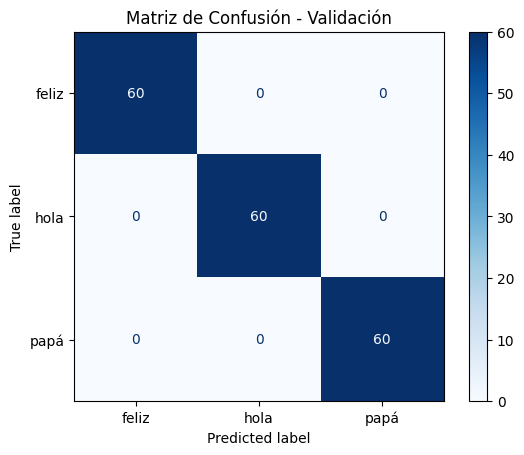


📊 Accuracy final - Entrenamiento: 1.00, Validación: 1.00
✅ Buen desempeño general


In [27]:
def train_model_from_npy(epochs=300):
    X, y, label_map = load_dataset()  # y debe ser one-hot con num_clases = len(label_map)
    print(f"✅ Total muestras: {X.shape[0]}, Clases: {len(label_map)}")
    # Sanity checks de shape/dtype (opcionales pero útiles)
    assert X.ndim == 3 and X.shape[1] == MODEL_FRAMES and X.shape[2] == LENGTH_KEYPOINTS, \
        f"X shape {X.shape} debe ser (N, {MODEL_FRAMES}, {LENGTH_KEYPOINTS})"
    assert y.ndim == 2, f"y debe ser one-hot (N, C); shape actual: {y.shape}"

    X = X.astype(np.float32)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
    )

    model = get_model(MODEL_FRAMES, output_length=y.shape[1])
    print("MODEL in/out (entrenamiento):", model.input_shape, "->", model.output_shape)

    early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=8,
        callbacks=[early_stop],
        verbose=1
    )

    # --- GUARDAR MODELO COMPLETO (.h5) ---
    model.save(MODEL_PATH)
    print(f"💾 Modelo guardado en: {MODEL_PATH}")

    # --- GUARDAR ORDEN DE CLASES (MUY IMPORTANTE) ---
    # label_map suele ser dict { "clase": idx }. Reconstruimos la lista por índice:
    num_classes = y.shape[1]
    classes = [None] * num_classes
    for cls, idx in label_map.items():
        classes[idx] = cls
    # Validación
    assert all(c is not None for c in classes), "label_map incompleto/inconsistente"

    with open(CLASSES_PATH, "w", encoding="utf-8") as f:
        json.dump({"classes": classes}, f, ensure_ascii=False, indent=2)
    print(f"📝 Clases guardadas en: {CLASSES_PATH}")
    print("MAPEO ENTRENAMIENTO:", {i: c for i, c in enumerate(classes)})

    # --- (Opcional) GUARDAR CONFIG PARA INFERENCIA ---
    with open(CONFIG_PATH, "w", encoding="utf-8") as f:
        json.dump({
            "target_frames": MODEL_FRAMES,
            "length_keypoints": LENGTH_KEYPOINTS
        }, f, ensure_ascii=False, indent=2)
    print(f"⚙️ Config guardada en: {CONFIG_PATH}")

    # 📊 Matriz de Confusión
    y_pred = model.predict(X_val)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_val, axis=1)

    cm = confusion_matrix(y_true, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format=".0f")
    plt.title("Matriz de Confusión - Validación")
    plt.show()

    # 📈 Diagnóstico
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"\n📊 Accuracy final - Entrenamiento: {train_acc:.2f}, Validación: {val_acc:.2f}")
    if abs(train_acc - val_acc) > 0.2:
        print("⚠️ Posible overfitting")
    elif max(history.history['val_accuracy']) < 0.6:
        print("⚠️ Posible underfitting")
    else:
        print("✅ Buen desempeño general")

    return model, {"classes": classes}

model, label_map = train_model_from_npy(epochs=150)

## 5. Validaciones

In [9]:
LENGTH_KEYPOINTS = 126

def get_model(max_length_frames, output_length: int):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(max_length_frames, LENGTH_KEYPOINTS), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(output_length, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [10]:
MODEL_PATH = "models/action.h5"
DATA_PATH = "data/frases"
WORDS = sorted(os.listdir(DATA_PATH))  # nombres de las clases
MODEL_FRAMES = 30
MIN_LENGTH_FRAMES = 10
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_POS = (10, 30)
FONT_SIZE = 1

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    return model.process(image)

def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]) if results.left_hand_landmarks else np.zeros((21, 3))
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]) if results.right_hand_landmarks else np.zeros((21, 3))
    return np.concatenate([lh, rh]).flatten()

def normalize_keypoints(keypoints, target_length=30):
    current_length = len(keypoints)
    if current_length == target_length:
        return keypoints
    elif current_length > target_length:
        step = current_length / target_length
        indices = np.arange(0, current_length, step).astype(int)[:target_length]
        return [keypoints[i] for i in indices]
    else:
        indices = np.linspace(0, current_length - 1, target_length)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if lower == upper:
                interpolated.append(keypoints[lower])
            else:
                interpolated.append(((1 - weight) * np.array(keypoints[lower]) + weight * np.array(keypoints[upper])).tolist())
        return interpolated

def draw_keypoints(image, results):
    mp_drawing = mp.solutions.drawing_utils
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

In [6]:
def evaluate_model(threshold=0.8, margin_frame=1, delay_frames=3, src=0):
    print("🟡 Cargando modelo...")
    model = load_model(MODEL_PATH)

    print("📷 Inicializando cámara...")
    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        print("❌ No se pudo abrir la cámara.")
        return

    sentence = []
    pred_label = ""
    pred_prob = 0.0
    kp_seq, count_frame, fix_frames = [], 0, 0
    recording = False

    with Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        print("🎥 Traductor en vivo iniciado. Presiona 'q' para salir.")
        while True:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ No se pudo leer el frame de la cámara.")
                break

            results = mediapipe_detection(frame, holistic)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    kp_frame = extract_keypoints(results)
                    kp_seq.append(kp_frame)
            else:
                if count_frame >= MIN_LENGTH_FRAMES + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        continue

                    kp_seq = kp_seq[: -(margin_frame + delay_frames)]
                    kp_normalized = normalize_keypoints(kp_seq, target_length=MODEL_FRAMES)
                    input_data = np.expand_dims(np.array(kp_normalized), axis=0)

                    prediction = model.predict(input_data, verbose=0)[0]
                    max_idx = np.argmax(prediction)
                    max_prob = prediction[max_idx]

                    if max_prob > threshold:
                        pred_label = WORDS[max_idx]
                        pred_prob = max_prob * 100
                        sentence.insert(0, pred_label)

                kp_seq = []
                count_frame = 0
                fix_frames = 0
                recording = False

            # Mostrar texto y porcentaje en ventana
            cv2.rectangle(frame, (0, 0), (640, 60), (245, 117, 16), -1)
            cv2.putText(frame, f'{pred_label.upper()} ({pred_prob:.1f}%)', FONT_POS, FONT, FONT_SIZE, (255, 255, 255), 2)

            draw_keypoints(frame, results)
            cv2.imshow('Traductor LSP', frame)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                print("🛑 Cerrando traductor.")
                break

        cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    evaluate_model()

🟡 Cargando modelo...
📷 Inicializando cámara...
🎥 Traductor en vivo iniciado. Presiona 'q' para salir.
🛑 Cerrando traductor.


In [11]:
from contextlib import contextmanager
def evaluate_video(
    video_path: str,
    threshold: float = 0.8,
    margin_frame: int = 1,
    delay_frames: int = 3,
    output: bool = True,
    show_window: bool = False,
):
    """
    Evalúa un video en archivo en lugar de la cámara.
    - Detecta ventanas de gesto (aparece mano -> desaparece) y predice con el modelo.
    - Genera un MP4 anotado con el texto (si output=True).
    - Devuelve una lista de detecciones con tiempos de inicio/fin y probabilidad.
    """
    if not os.path.isfile(video_path):
        print(f"❌ No existe el archivo: {video_path}")
        return []

    print("🟡 Cargando modelo...")
    model = load_model(MODEL_PATH)

    print(f"🎬 Abriendo video: {video_path}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("❌ No se pudo abrir el video.")
        return []

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)  or 640)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 480)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    # Preparar salida de video
    writer = None
    out_path = None
    if output:
        base = os.path.splitext(os.path.basename(video_path))[0]
        out_path = f"resultado_{base}.mp4"
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    detections = []  # cada item: {label, prob, start_frame, end_frame, start_time, end_time}

    kp_seq, count_frame, fix_frames = [], 0, 0
    recording = False

    pred_label = ""
    pred_prob = 0.0
    overlay_cooldown = 0  # frames para mostrar el texto en el video

    # --- MediaPipe Holistic context manager (usa tu helper si lo tienes) ---
    import mediapipe as mp
    with mp.solutions.holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        frame_idx = 0
        print("▶️ Procesando frames...")
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Detección con tu helper (si ya lo tienes). Si no, usa el pipeline normal de MP:
            # results = mediapipe_detection(frame, holistic)
            # Si tu mediapipe_detection ya convierte a RGB y llama holistic.process, úsalo.
            # Aquí uso el helper por compatibilidad con tu notebook:
            results = mediapipe_detection(frame, holistic)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    kp_frame = extract_keypoints(results)  # Debe regresar vector de 126 (o lo que uses)
                    kp_seq.append(kp_frame)
            else:
                # Sección de cierre del gesto
                if count_frame >= MIN_LENGTH_FRAMES + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        # seguimos acumulando el "colchón" de cierre
                    else:
                        # recorta margen + delay
                        if margin_frame + delay_frames > 0:
                            kp_seq = kp_seq[:-(margin_frame + delay_frames)] if len(kp_seq) > (margin_frame + delay_frames) else kp_seq

                        # normaliza y remuestrea a MODEL_FRAMES
                        kp_normalized = normalize_keypoints(kp_seq, target_length=MODEL_FRAMES)  # (30, D)
                        input_data = np.expand_dims(np.array(kp_normalized), axis=0)            # (1,30,D)

                        prediction = model.predict(input_data, verbose=0)[0]
                        max_idx = int(np.argmax(prediction))
                        max_prob = float(prediction[max_idx])

                        if max_prob > threshold:
                            pred_label = WORDS[max_idx]
                            pred_prob = max_prob * 100.0
                            overlay_cooldown = int(fps * 0.7)  # muestra ~0.7s el texto

                            # marca temporal (aprox): usamos frame actual como fin, y restamos la duración de la ventana
                            end_frame = frame_idx
                            dur_frames = len(kp_seq)
                            start_frame = max(0, end_frame - dur_frames)
                            detections.append({
                                "label": pred_label,
                                "prob": pred_prob,
                                "start_frame": start_frame,
                                "end_frame": end_frame,
                                "start_time": start_frame / fps,
                                "end_time": end_frame / fps,
                            })

                        # reset para siguiente gesto
                        kp_seq, count_frame, fix_frames, recording = [], 0, 0, False
                else:
                    # No hubo suficiente material para formar gesto
                    kp_seq, count_frame, fix_frames, recording = [], 0, 0, False

            # --- Overlay de texto (si hubo predicción reciente) ---
            if overlay_cooldown > 0:
                cv2.rectangle(frame, (0, 0), (max(300, width // 2), 60), (245, 117, 16), -1)
                cv2.putText(frame, f'{pred_label.upper()} ({pred_prob:.1f}%)',
                            (20, 40), FONT, FONT_SIZE, (255, 255, 255), 2)
                overlay_cooldown -= 1

            # Dibuja keypoints si quieres mantener tu visualización
            try:
                draw_keypoints(frame, results)
            except Exception:
                pass  # por si tu helper no está cargado aquí

            # Escribir/frame y/o mostrar
            if writer is not None:
                writer.write(frame)

            if show_window:
                cv2.imshow('Traductor LSP (video)', frame)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break

            frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    if show_window:
        cv2.destroyAllWindows()

    # --- Resumen ---
    print("✅ Detecciones:")
    if not detections:
        print("   (sin resultados sobre el umbral)")
    else:
        for i, d in enumerate(detections, 1):
            print(f" {i:02d}. {d['label']}  {d['prob']:.1f}%  "
                  f"{d['start_time']:.2f}s → {d['end_time']:.2f}s  "
                  f"(frames {d['start_frame']}–{d['end_frame']})")

    if out_path:
        print(f"💾 Video anotado: {out_path}")

    return detections

In [18]:
detecciones = evaluate_video(
    "prueba4.mp4",   # ruta a tu video
    threshold=0.8,   # probabilidad mínima aceptada
    output=True,     # genera un video anotado
    show_window=False # pon True si quieres que se abra una ventana en vivo
)

print(detecciones)

🟡 Cargando modelo...
🎬 Abriendo video: prueba4.mp4
▶️ Procesando frames...
✅ Detecciones:
 01. hola  100.0%  1.61s → 2.74s  (frames 40–68)
 02. feliz  100.0%  4.07s → 5.48s  (frames 101–136)
 03. papá  100.0%  7.13s → 9.23s  (frames 177–229)
 04. papá  100.0%  10.68s → 11.20s  (frames 265–278)
 05. hola  100.0%  14.14s → 15.07s  (frames 351–374)
💾 Video anotado: resultado_prueba4.mp4
[{'label': 'hola', 'prob': 99.97212290763855, 'start_frame': 40, 'end_frame': 68, 'start_time': 1.6118926829268292, 'end_time': 2.7402175609756094}, {'label': 'feliz', 'prob': 99.97105002403259, 'start_frame': 101, 'end_frame': 136, 'start_time': 4.0700290243902435, 'end_time': 5.480435121951219}, {'label': 'papá', 'prob': 99.9666690826416, 'start_frame': 177, 'end_frame': 229, 'start_time': 7.132625121951219, 'end_time': 9.228085609756096}, {'label': 'papá', 'prob': 99.9556839466095, 'start_frame': 265, 'end_frame': 278, 'start_time': 10.678789024390243, 'end_time': 11.202654146341462}, {'label': 'hola', 